/Users/aidanhsu/Documents/gaus-proc/.venv/lib/python3.12/site-packages/numpy/lib/_function_base_impl.py:4620: RuntimeWarning: invalid value encountered in subtract
  diff_b_a = subtract(b, a)
/Users/aidanhsu/Documents/gaus-proc/.venv/lib/python3.12/site-packages/numpy/lib/_function_base_impl.py:4620: RuntimeWarning: invalid value encountered in subtract
  diff_b_a = subtract(b, a)
/Users/aidanhsu/Documents/gaus-proc/.venv/lib/python3.12/site-packages/numpy/lib/_function_base_impl.py:4620: RuntimeWarning: invalid value encountered in subtract
  diff_b_a = subtract(b, a)
/Users/aidanhsu/Documents/gaus-proc/.venv/lib/python3.12/site-packages/numpy/lib/_function_base_impl.py:4620: RuntimeWarning: invalid value encountered in subtract
  diff_b_a = subtract(b, a)
/Users/aidanhsu/Documents/gaus-proc/.venv/lib/python3.12/site-packages/numpy/lib/_function_base_impl.py:4620: RuntimeWarning: invalid value encountered in subtract
  diff_b_a = subtract(b, a)


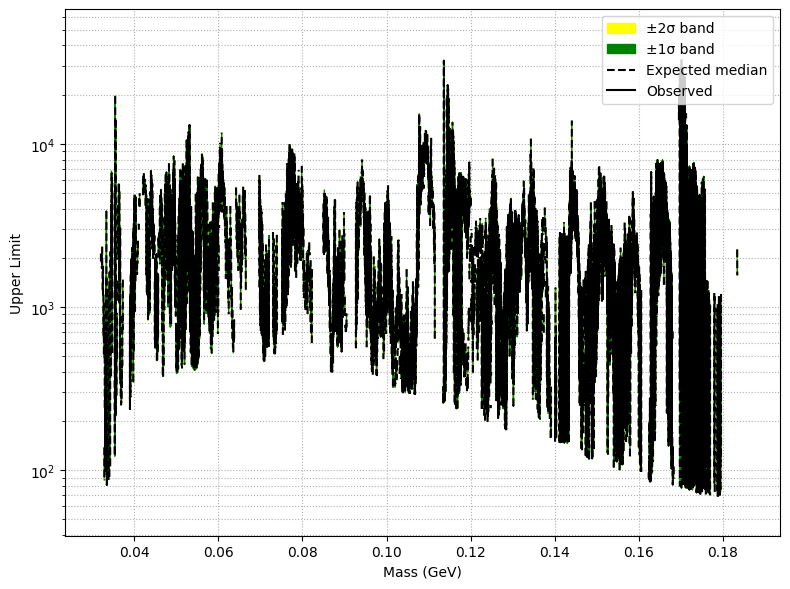

In [3]:
import glob
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# ─── CONFIG ─────────────────────────────────────────────────────────
# folder containing your many expected‐limit CSVs (one per toy)
expected_folder = "ul_tables_1.5_sigma"  

# your observed upper‐limit CSV
observed_file = "combined_UL_1.5_sigma_2_blind.csv"

# exact column‐names in those CSVs:
mass_col = "Mass"            # e.g. 0.033, 0.0331, 0.0332, ...
ul_col   = "Upper Limit"     # the limit values
# ────────────────────────────────────────────────────────────────────

# 1) load all of the expected‐limit files into one DataFrame
exp_files = sorted(glob.glob(f"{expected_folder}/UL_*.csv"))
if not exp_files:
    raise RuntimeError(f"No expected‐limit CSVs found in {expected_folder!r}")

# read each into a Series (indexed by mass), then concat as columns
exp_series = [
    pd.read_csv(fn).set_index(mass_col)[ul_col]
    for fn in exp_files
]
exp_df = pd.concat(exp_series, axis=1)
exp_df.sort_index(inplace=True)   # ensures mass is monotonic

# 2) compute the quantiles at each mass
q_lo2  = exp_df.quantile(0.025, axis=1)
q_lo1  = exp_df.quantile(0.16,  axis=1)
q_med  = exp_df.quantile(0.5,   axis=1)
q_hi1  = exp_df.quantile(0.84,  axis=1)
q_hi2  = exp_df.quantile(0.975, axis=1)

# 3) load the observed limits
obs = (
    pd.read_csv(observed_file)
      .set_index(mass_col)[ul_col]
)
obs = obs.reindex(exp_df.index)  # align to same mass grid

# 4) plot the “Brazil” bands
fig, ax = plt.subplots(figsize=(8,6))
ax.fill_between(exp_df.index, q_lo2, q_hi2, color='yellow', label='±2σ band')
ax.fill_between(exp_df.index, q_lo1, q_hi1, color='green',  label='±1σ band')
ax.plot(exp_df.index, q_med, ls='--', color='black', label='Expected median')
ax.plot(exp_df.index, obs,   ls='-',  color='black', label='Observed')

ax.set_xlabel("Mass (GeV)")
ax.set_ylabel("Upper Limit")
ax.set_yscale('log')
ax.grid(True, which='both', ls=':')
ax.legend(loc='upper right')

plt.tight_layout()
plt.show()


In [23]:
#!/usr/bin/env python
import sys
import numpy as np
import pandas as pd

# add your project root (so that `gp` imports work)
sys.path.append("..")

from gp import plt, label, limit_setting

def make_brazil(
    results_file: str,
    n_toys: int = 20000,
    seed: int = 1,
):
    """
    Read in your ‘search‐results.csv’ with columns
      - mass
      - prediction
      - uncertainty
      - observation
    then generate Poisson toys, compute upper limits,
    and draw the ±1σ/±2σ “Brazil bands” + median expected + observed.
    """
    

    # 1) load your search‐results table
    results = pd.read_csv(results_file)
    masses = results["mass"].to_numpy()
    bkgd   = results["prediction"].to_numpy()
    unc    = results["uncertainty"].to_numpy()
    obs    = results["observation"].to_numpy()
    
    for p in range(len(results.index)):
        if int(results.loc[p, 'prediction']) <= 0 or int(results.loc[p, 'uncertainty'] >= 10000):
            results = results.drop(p)

        
    # 2) toy‐experiment generation
    rng = np.random.default_rng(seed)
    # smear the prediction by its uncertainty, then Poisson‑sample
    toy_counts = rng.poisson(
        lam = rng.normal(loc=bkgd, scale=unc, size=(n_toys, len(bkgd)))
    )

    # 3) compute upper limit for each toy at each mass
    #    (limit_setting._single_bin_cls can take array inputs)
    toy_ul = limit_setting._single_bin_cls(
        bkgd[np.newaxis, :],   # shape (1, n_masses)
        toy_counts              # shape (n_toys, n_masses)
    )

    # 4) extract quantiles: 2.5%, 16%, 50%, 84%, 97.5%
    q2_lo, q1_lo, q_med, q1_hi, q2_hi = np.quantile(
        toy_ul,
        [0.025, 0.16, 0.5, 0.84, 0.975],
        axis=0
    )

    # 5) observed upper limit curve
    obs_ul = limit_setting._single_bin_cls(bkgd, obs)

    # 6) plotting
    fig, ax = plt.subplots(figsize=(8, 6))
    ax.fill_between(masses, q2_lo, q2_hi, color='yellow', label='±2σ band')
    ax.fill_between(masses, q1_lo, q1_hi, color='green',  label='±1σ band')
    ax.plot(masses, q_med,  ls='--', color='black', label='Median Expected')
    ax.plot(masses, obs_ul, ls='-',  color='black', label='Observed')

    ax.set_xlabel("Search Mass / GeV")
    ax.set_ylabel("Upper Limit")
    #ax.set_yscale('log')
    ax.grid(True, which='both', ls=':')
    ax.legend(loc='upper right')

    # add your experiment label or year if desired
    label(dataset='Your Dataset')

    plt.tight_layout()
    plt.xlim(0.04, 0.140)
    plt.show()


make_brazil("outputs_2016_rbn1_smeared/search-results.csv", n_toys=10000, seed=1)


ValueError: lam < 0 or lam contains NaNs

/Users/aidanhsu/Documents/gaus-proc/.venv/lib/python3.12/site-packages/sklearn/gaussian_process/_gpr.py:659: ConvergenceWarning: lbfgs failed to converge (status=2):
ABNORMAL_TERMINATION_IN_LNSRCH.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
  _check_optimize_result("lbfgs", opt_res)
/Users/aidanhsu/Documents/gaus-proc/.venv/lib/python3.12/site-packages/numpy/lib/_function_base_impl.py:4620: RuntimeWarning: invalid value encountered in subtract
  diff_b_a = subtract(b, a)


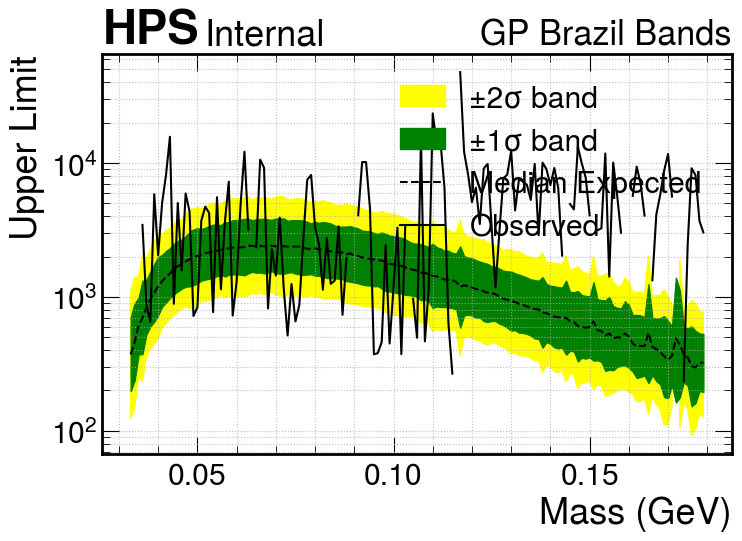

In [17]:
# %% [markdown]
# Brazil Bands with GP-based Upper Limits
#
# This notebook shows how to:
# 1. Use GaussianProcessModel to estimate background and uncertainty in the blind region for each mass
# 2. Generate toy experiments via Poisson fluctuations
# 3. Compute upper limits for each toy
# 4. Plot the ±1σ/±2σ Brazil bands, median expected, and observed limits

# %%
%matplotlib inline
import sys
sys.path.append("..")
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from gp import GaussianProcessModel, kernels, _hist, limit_setting, label

# %% [markdown]
# ## Configuration

# %%
root_file   = 'EventSelection_Data_10Percent.root'
hist_name   = 'h_Minv_General_Final_1'
masses      = np.arange(0.033, 0.179+1e-9, 0.001)  # GeV
coeffs      = [0.00038, 0.041, -0.27, 3.49, -11.11]
rebin       = 1
kernel      = (
    kernels.WhiteKernel(noise_level=7e3)
    + kernels.RBF(length_scale=0.016)
      * kernels.DotProduct(sigma_0=2.5e4)
)
n_restarts  = 5

# %% [markdown]
# ## Helper functions

# %%
def sigma(m, coeffs):
    return sum(c * m**i for i, c in enumerate(coeffs))

# %%
def estimate_background(mass):
    """
    Fit GP outside the blind region and return
    predicted background sum and its uncertainty in the blind
    region, along with the observed count.
    """
    σ = sigma(mass, coeffs)
    lower, upper = mass - 3*σ, mass + 3*σ
    blind = (mass - 2*σ, mass + 2*σ)

    manip = _hist.manipulation.rebin_and_limit(rebin, lower, upper)
    gp_mod = GaussianProcessModel(
        h=(root_file, hist_name),
        kernel=kernel,
        n_restarts_optimizer=n_restarts,
        blind_range=blind,
        modify_histogram=manip
    )

    # extract histogram axes and values
    X      = gp_mod.histogram.axes[0].centers
    values = gp_mod.histogram.values()

    # select points outside blind to train
    mask_out = (X < blind[0]) | (X > blind[1])
    X_out    = X[mask_out].reshape(-1, 1)
    y_out    = values[mask_out]

    # find underlying sklearn GPR instance
    if hasattr(gp_mod, 'model'):
        gpr = gp_mod.model
    elif hasattr(gp_mod, '_model'):
        gpr = gp_mod._model
    else:
        raise AttributeError("No sklearn model found on GaussianProcessModel")

    # re-train on the non-blind region
    gpr.fit(X_out, y_out)

    # predict mean & std inside blind
    mask_blind  = (X >= blind[0]) & (X <= blind[1])
    X_blind     = X[mask_blind].reshape(-1, 1)
    mean_b, std_b = gpr.predict(X_blind, return_std=True)

    pred   = np.sum(mean_b)
    uncert = np.sqrt(np.sum(std_b**2))
    obs    = np.sum(values[mask_blind])
    return pred, uncert, obs

# %% [markdown]
# ## Build `search-results.csv`

# %%
results = []
for m in masses:
    pred, unc, obs = estimate_background(m)
    results.append((m, pred, unc, obs))

results_df = pd.DataFrame(
    results,
    columns=['mass', 'prediction', 'uncertainty', 'observation']
)
results_df.to_csv('search-results.csv', index=False)
results_df.head()

# %% [markdown]
# ## Generate Brazil Bands

# %%
rng = np.random.default_rng(seed=1)
# smear prediction by its uncertainty, then Poisson sample
toy_counts = rng.poisson(
    lam=rng.normal(
        loc=results_df.prediction.values,
        scale=results_df.uncertainty.values,
        size=(10000, len(results_df))
    )
)

# compute upper limits per toy
toy_ul = limit_setting._single_bin_cls(
    results_df.prediction.values[np.newaxis, :],
    toy_counts
)

# quantiles for ±2σ, ±1σ, median
q2_lo, q1_lo, q_med, q1_hi, q2_hi = np.quantile(
    toy_ul,
    [0.025, 0.16, 0.5, 0.84, 0.975],
    axis=0
)
# observed limit curve
obs_ul = limit_setting._single_bin_cls(
    results_df.prediction.values,
    results_df.observation.values
)

# %% [markdown]
# ## Plot Brazil Bands

# %%
plt.figure(figsize=(8,6))
plt.fill_between(results_df.mass, q2_lo, q2_hi, color='yellow', label='±2σ band')
plt.fill_between(results_df.mass, q1_lo, q1_hi, color='green',  label='±1σ band')
plt.plot(results_df.mass, q_med,  ls='--', color='black', label='Median Expected')
plt.plot(results_df.mass, obs_ul, ls='-',  color='black', label='Observed')
plt.yscale('log')
plt.xlabel('Mass (GeV)')
plt.ylabel('Upper Limit')
plt.legend(loc='upper right')
plt.grid(True, which='both', ls=':')
label(dataset='GP Brazil Bands')
plt.tight_layout()
plt.show()


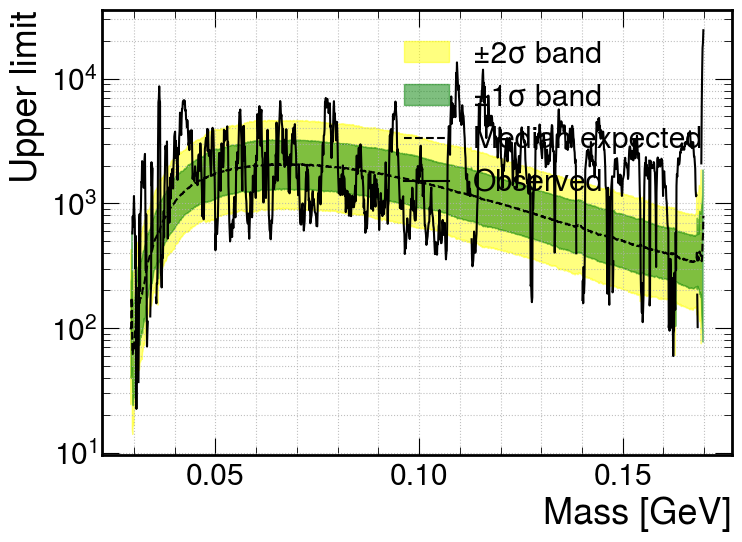

In [18]:
import pandas as pd
import matplotlib.pyplot as plt

# Load Brazil‐band CSV
df = pd.read_csv('combined_UL_brazil.csv')

m = df['Mass']
lo2, hi2 = df['Lower 2σ'], df['Upper 2σ']
lo1, hi1 = df['Lower 1σ'], df['Upper 1σ']
med       = df['Median UL']
obs       = df['Observed UL']

plt.figure(figsize=(8,6))
plt.fill_between(m, lo2, hi2, color='yellow', alpha=0.5, label='±2σ band')
plt.fill_between(m, lo1, hi1, color='green',  alpha=0.5, label='±1σ band')
plt.plot(m, med, '--k', label='Median expected')
plt.plot(m, obs, '-k',  label='Observed')
plt.yscale('log')
plt.xlabel('Mass [GeV]')
plt.ylabel('Upper limit')
plt.legend(loc='upper right')
plt.grid(which='both', linestyle=':')
plt.tight_layout()
plt.show()
